## Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import plotly.graph_objects as go
import umap
from scipy.stats import ttest_ind, chi2_contingency, f_oneway, shapiro, levene
from statsmodels.formula.api import ols
import plotly.express as px

In [ ]:
## setting theme
sns.set_theme(style='whitegrid', palette='Spectral')

## Data collection

In [3]:
# collecting data from the apples dataset
df = pd.read_csv('Apples.csv')


## Data exploration

In [7]:
## Checking for the information for example Dtype , null, column labels and non-null objects
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   object 
 8   Quality      4000 non-null   object 
dtypes: float64(7), object(2)
memory usage: 281.4+ KB


## Data preprocessing

In [8]:
# Converts acidity value from an object to numeric value. Coerce handles any errors and we drop the object values.
# The info prompt shows that the acidity value is now in float64 format
df['Acidity'] = pd.to_numeric(df['Acidity'], errors='coerce')

df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4000 non-null   float64
 8   Quality      4000 non-null   object 
dtypes: float64(8), object(1)
memory usage: 312.5+ KB


In [9]:
# Setting the seaborn theme for the entire script
sns.set_theme(style='whitegrid', palette='deep')
sns.color_palette('Oranges')

[(0.9955709342560554, 0.8907958477508651, 0.7855132641291811),
 (0.9921568627450981, 0.7769934640522875, 0.5727028066128412),
 (0.9921568627450981, 0.6280507497116494, 0.34226835832372166),
 (0.9648442906574395, 0.47100346020761247, 0.14197616301422528),
 (0.8782929642445213, 0.31990772779700116, 0.024405997693194924),
 (0.6768627450980392, 0.22089965397923875, 0.010749711649365626)]

In [10]:
# Statistical summary
df.describe()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,1999.500000,-0.503015,-0.989547,-0.470479,0.985478,0.512118,0.498277,0.076877
std,1154.844867,1.928059,1.602507,1.943441,1.402757,1.930286,1.874427,2.110270
min,0.000000,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599,-7.010538
25%,999.750000,-1.816765,-2.011770,-1.738425,0.062764,-0.801286,-0.771677,-1.377424
50%,1999.500000,-0.513703,-0.984736,-0.504758,0.998249,0.534219,0.503445,0.022609
75%,2999.250000,0.805526,0.030976,0.801922,1.894234,1.835976,1.766212,1.510493
max,3999.000000,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837,7.404736


In [61]:
df.dtypes

A_id           float64
Size           float64
Weight         float64
Sweetness      float64
Crunchiness    float64
Juiciness      float64
Ripeness       float64
Acidity        float64
Quality         object
dtype: object

In [62]:
print(df['Quality'].dtype)  # shows data type of the Quality column
print(df['Quality'].head())

object
0    good
1    good
2     bad
3    good
4    good
Name: Quality, dtype: object


In [11]:
# exploring columns in the dataset
df.columns

Index(['A_id', 'Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness',
       'Ripeness', 'Acidity', 'Quality'],
      dtype='object')

In [12]:
# Creating a dataframe containing 
data = ['Size', 'Weight', 'Crunchiness', 'Juiciness', 'Ripeness','Acidity']

In [13]:
# Descriptive statistics
ds = pd.DataFrame({
    'Mean': df[data].mean(),
    'Median': df[data].median(),
    'Mode': df[data].mode().iloc[0],
    'Variance': df[data].var(),
    'Standard Deviation': df[data].std(),
    'Skewness': df[data].skew(),
    'Kurtosis': df[data].kurt(),
})

In [14]:
ds.head()

,Mean,Median,Mode,Variance,Standard Deviation,Skewness,Kurtosis
Size,-0.503015,-0.513703,-7.151703,3.717410,1.928059,-0.002437,-0.083341
Weight,-0.989547,-0.984736,-7.149848,2.568029,1.602507,0.003102,0.359050
Crunchiness,0.985478,0.998249,-6.055058,1.967728,1.402757,0.000230,0.722020
Juiciness,0.512118,0.534219,-5.961897,3.726003,1.930286,-0.113421,0.028735
Ripeness,0.498277,0.503445,-5.864599,3.513476,1.874427,-0.008764,-0.071850


<Figure size 1000x600 with 0 Axes>

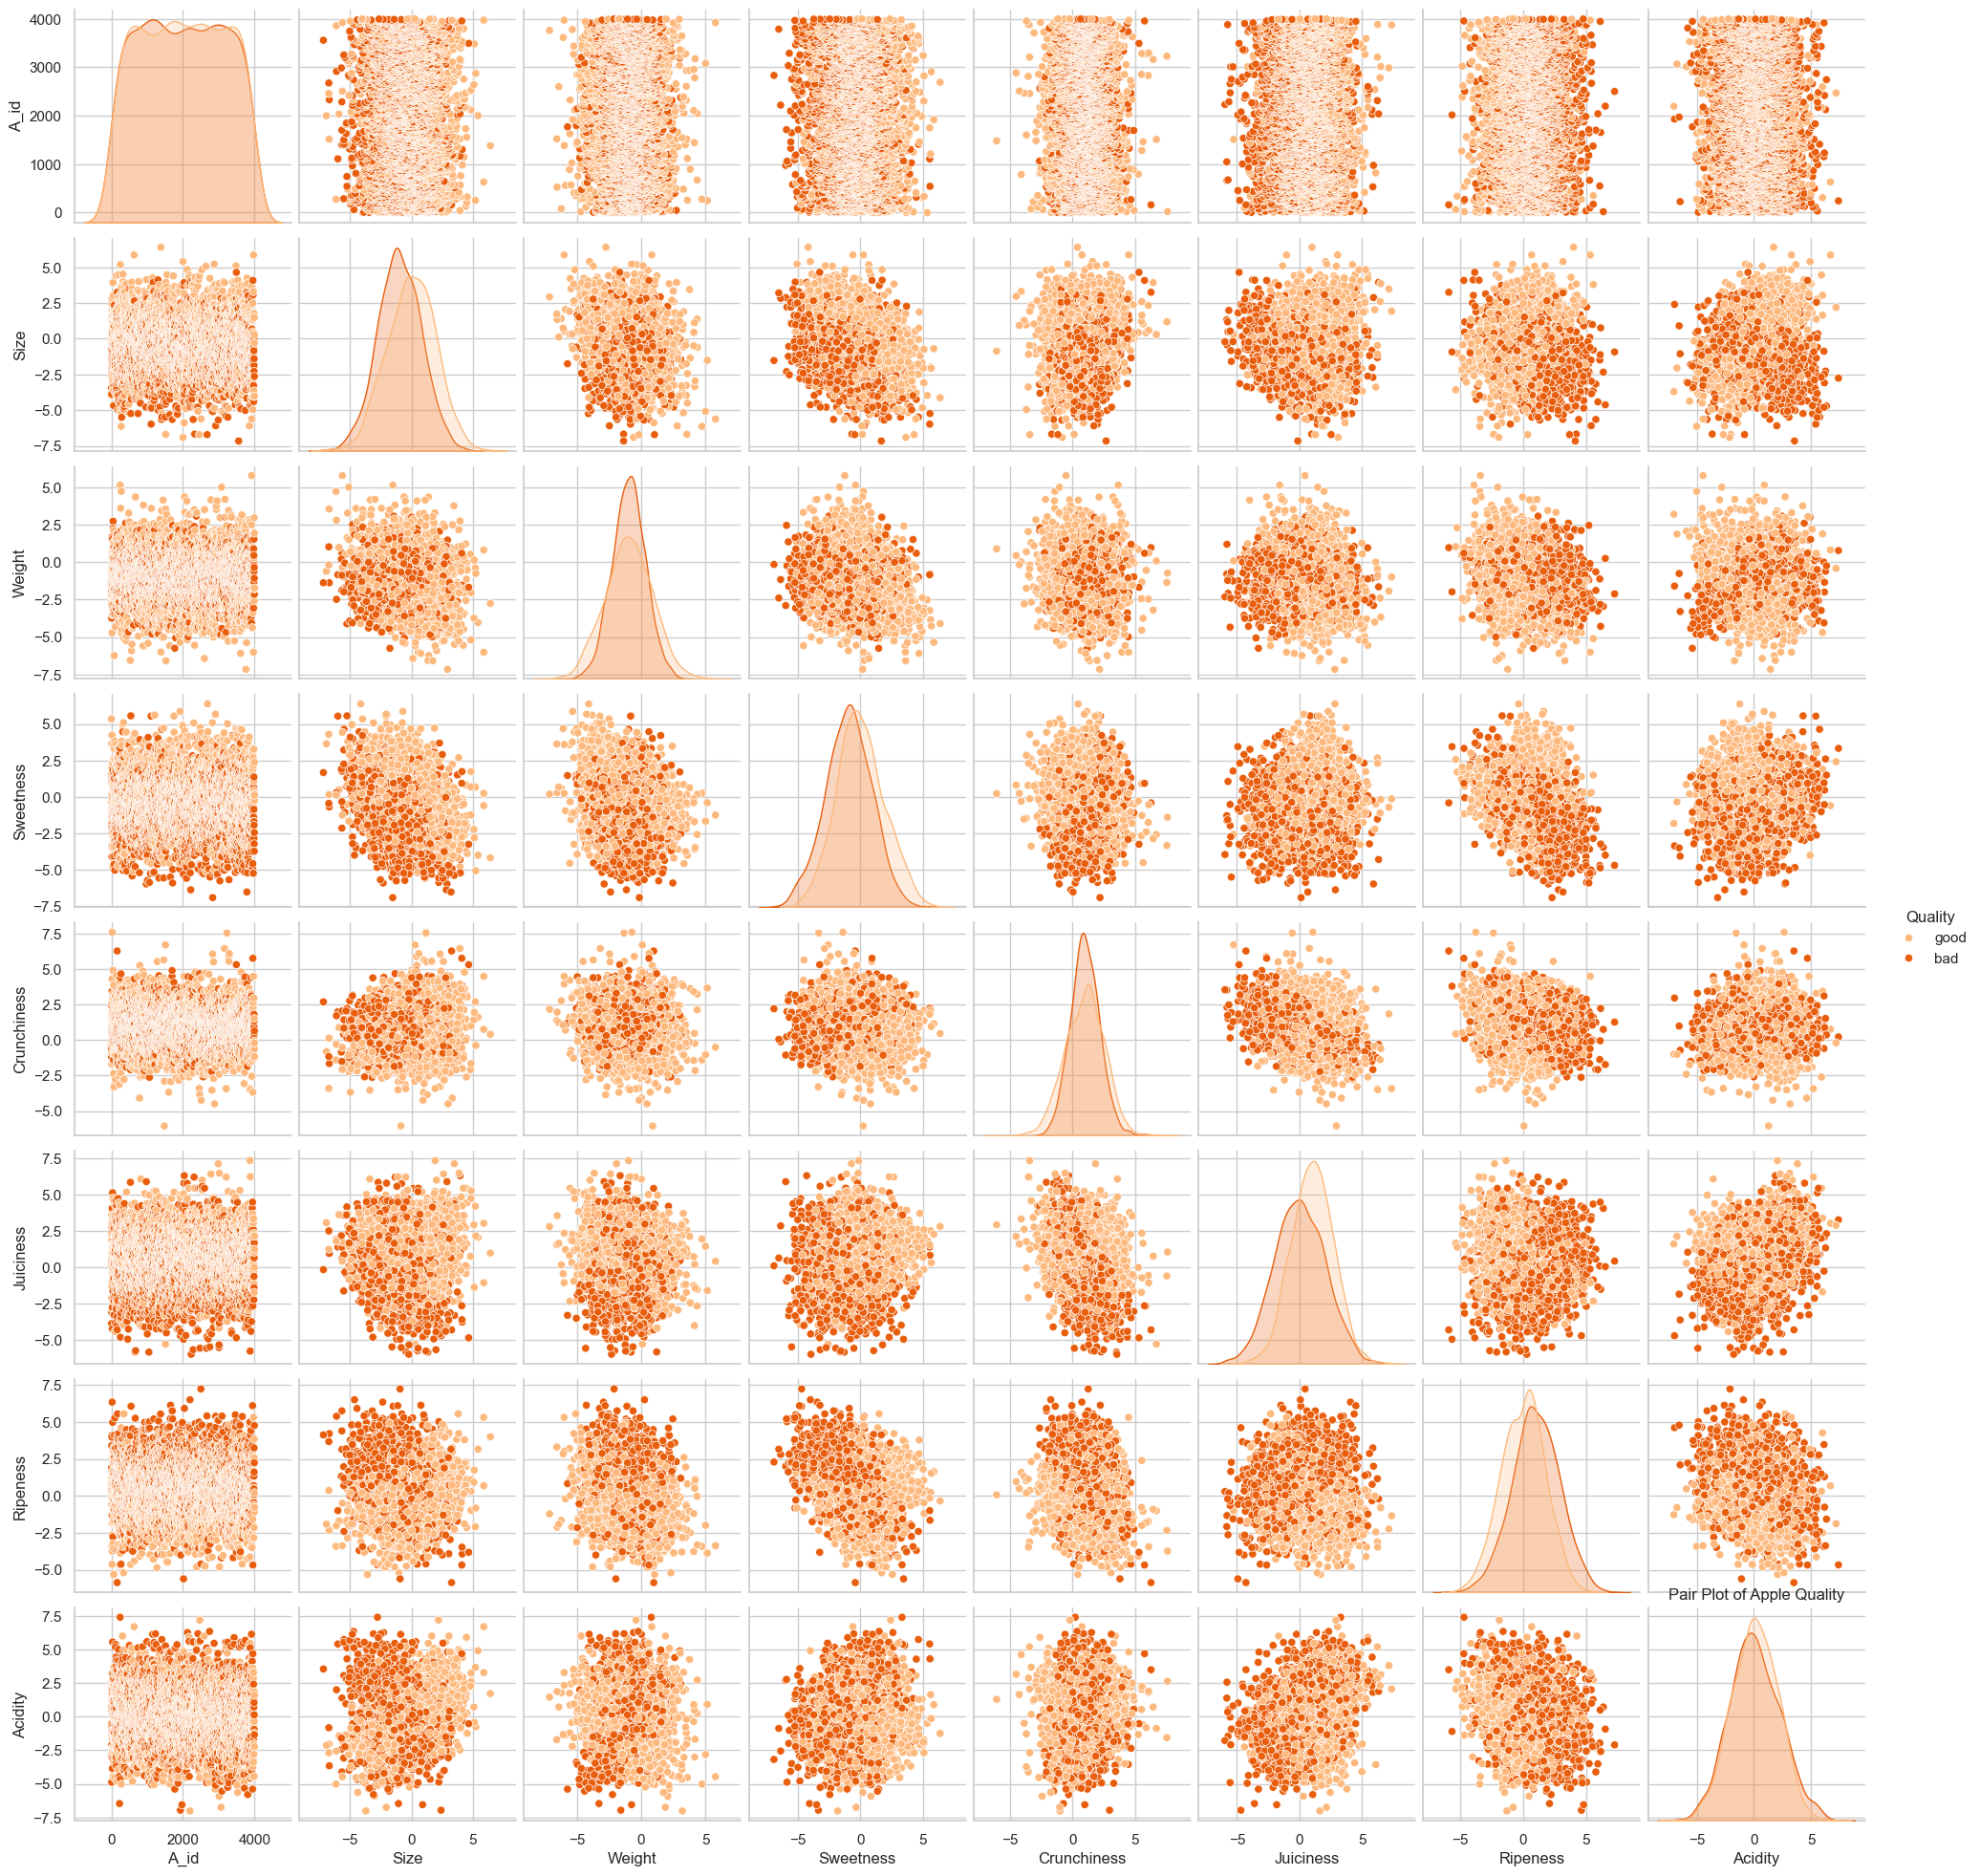

In [ ]:
# Creating a pair plot for the distribution of apple quality
plt.figure(figsize=(10, 6))
sns.pairplot(df, hue='Quality', palette='Oranges')
plt.title('Pair Plot of Apple Quality')
plt.show()

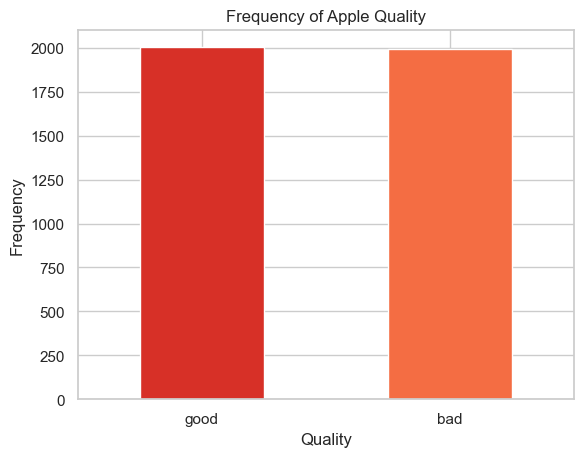

In [16]:
Quality_counts = df['Quality'].value_counts()
Quality_counts.plot(kind='bar', color=['#d73027','#f46d43'], title='Frequency of Apple Quality')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_842/269103850.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Quality', y='Size', data=df, palette='Oranges')


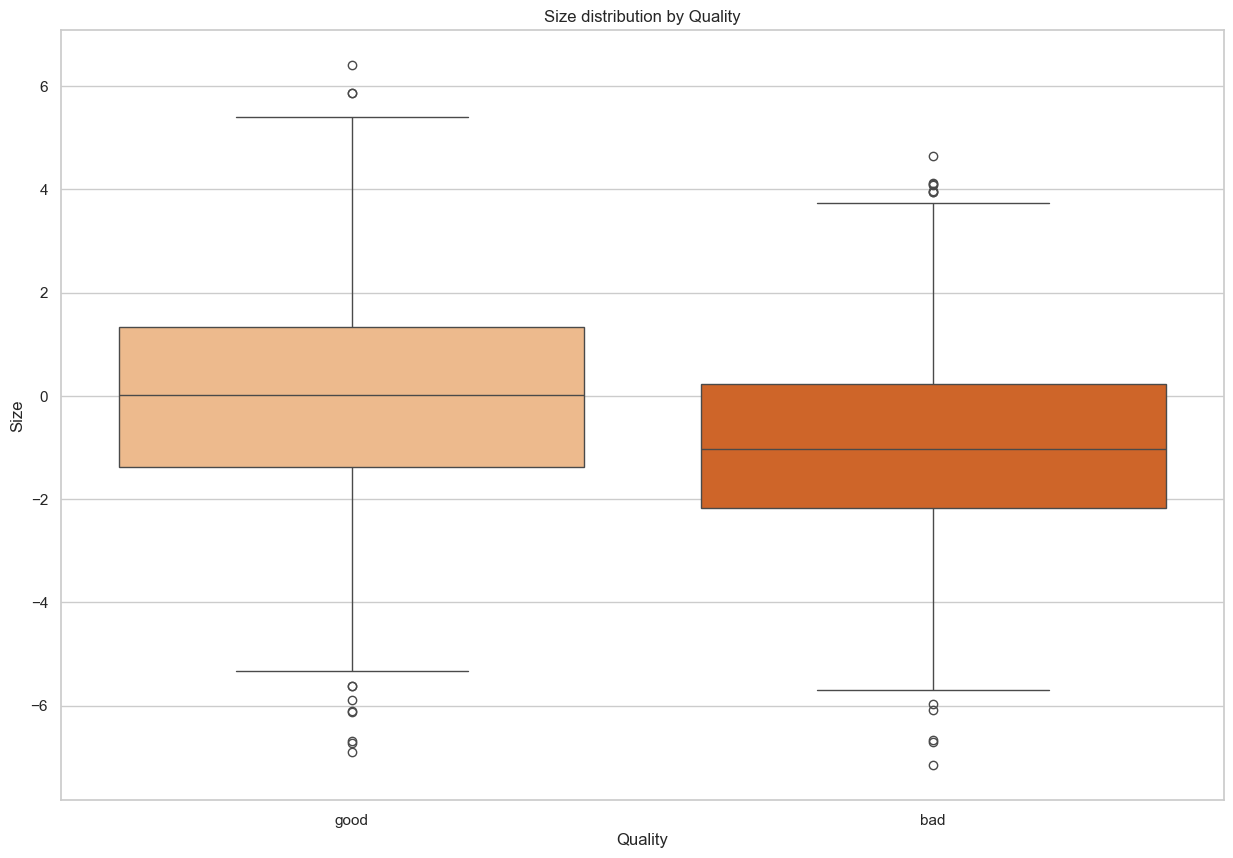

In [17]:
# visualization
plt.figure(figsize=(15, 10))
sns.boxplot(x='Quality', y='Size', data=df, palette='Oranges')
plt.title('Size distribution by Quality')
plt.xlabel('Quality')
plt.ylabel('Size')
plt.show()

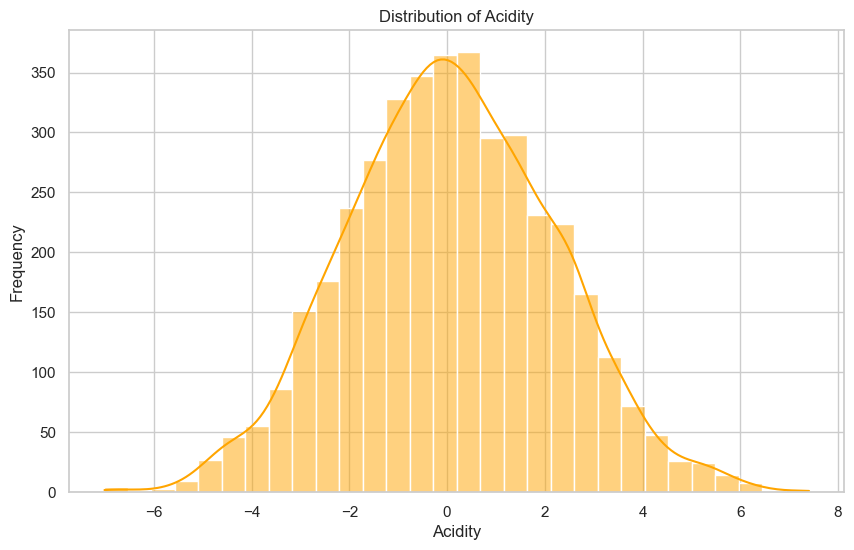

In [18]:
# Visualizing the distribution of acidity
plt.figure(figsize=(10, 6))
sns.histplot(df['Acidity'], bins=30, kde=True, color='orange')
plt.title('Distribution of Acidity')
plt.xlabel('Acidity')
plt.ylabel('Frequency')
plt.show()

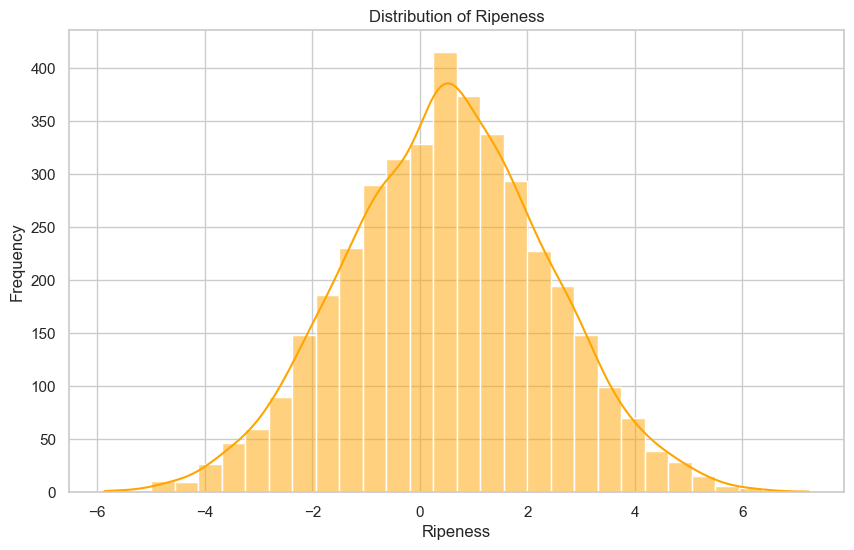

In [19]:

# Visualizing the distribution of ripeness
plt.figure(figsize=(10, 6))
sns.histplot(df['Ripeness'], bins=30, kde=True, color='orange')
plt.title('Distribution of Ripeness')
plt.xlabel('Ripeness')
plt.ylabel('Frequency')
plt.show()


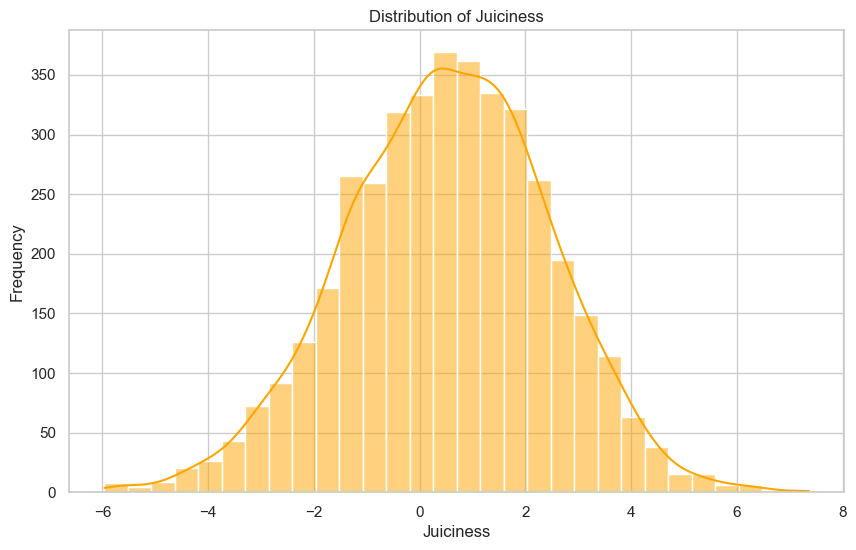

In [20]:
# Visualizing the distribution of juiciness 
plt.figure(figsize=(10, 6))
sns.histplot(df['Juiciness'], bins=30, kde=True, color='orange')
plt.title('Distribution of Juiciness')
plt.xlabel('Juiciness')
plt.ylabel('Frequency')
plt.show()

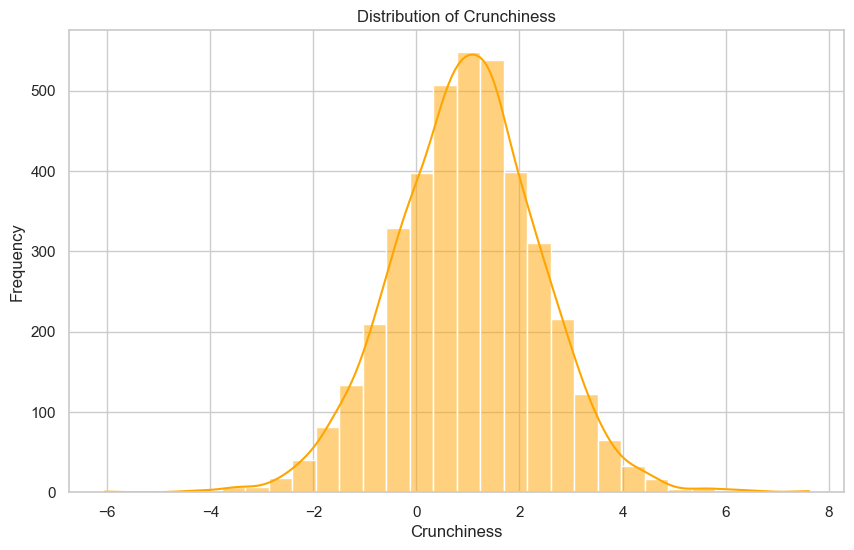

In [ ]:

# Visualizing the distribution of crunchiness
plt.figure(figsize=(10, 6))
sns.histplot(df['Crunchiness'], bins=30, kde=True, color='orange')
plt.title('Distribution of Crunchiness')
plt.xlabel('Crunchiness')
plt.ylabel('Frequency')
plt.show()

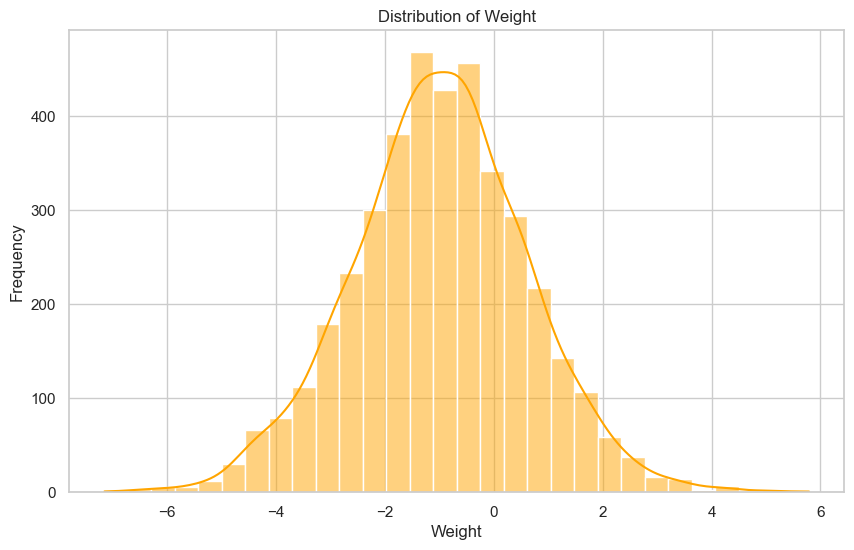

In [22]:

# Visualizing the distribution of weight
plt.figure(figsize=(10, 6))
sns.histplot(df['Weight'], bins=30, kde=True, color='orange')   
plt.title('Distribution of Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.show()


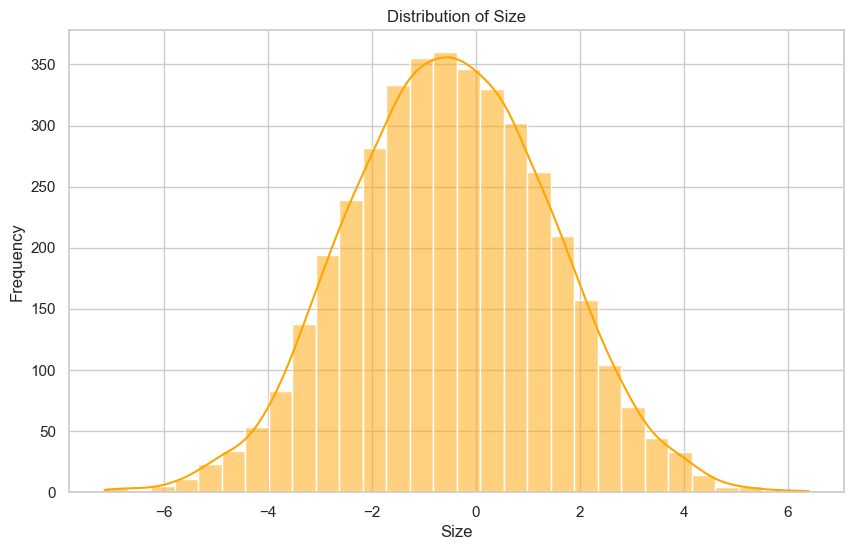

In [23]:

# Visualizing the distribution of size
plt.figure(figsize=(10, 6))
sns.histplot(df['Size'], bins=30, kde=True, color='orange')
plt.title('Distribution of Size')
plt.xlabel('Size')
plt.ylabel('Frequency')
plt.show()

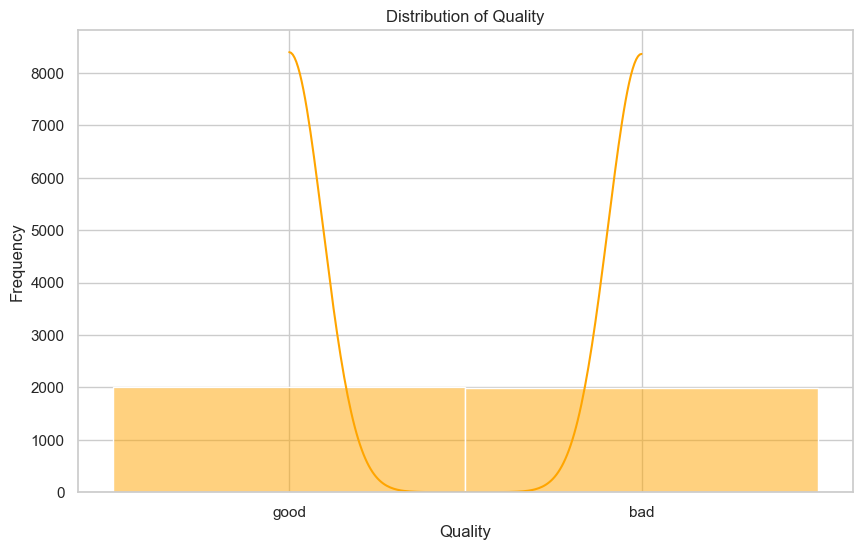

In [24]:
# Visualizing the distribution of quality
plt.figure(figsize=(10, 6))
sns.histplot(df['Quality'], bins=30, kde=True, color='orange')
plt.title('Distribution of Quality')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.show()

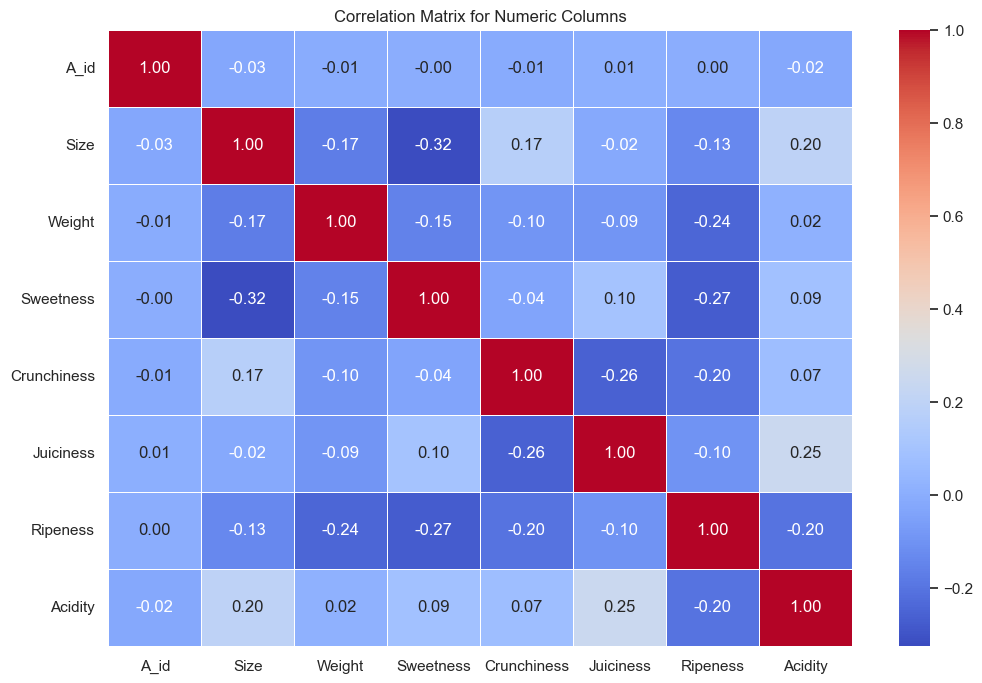

In [25]:
# correlation matrix for numeric values only
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[numeric_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix for Numeric Columns')
plt.show()

In [26]:
# Inferential statistics
# T-test for Size
from scipy import stats
# Assuming 'Quality' is binary (0 and 1)
quality_0 = df[df['Quality'] == 0]['Size']
quality_1 = df[df['Quality'] == 1]['Size']
t_stat, p_value = stats.ttest_ind(quality_0, quality_1)
print(f"T-test for Size: t-statistic = {t_stat}, p-value = {p_value}")



T-test for Size: t-statistic = nan, p-value = nan


/Users/phionanamugga/Documents/coding/datascience/SA_Apple_Quality/venv/lib/python3.13/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [27]:
# T-test for Weight
quality_0 = df[df['Quality'] == 0]['Weight']
quality_1 = df[df['Quality'] == 1]['Weight']
t_stat, p_value = stats.ttest_ind(quality_0, quality_1)     
print(f"T-test for Weight: t-statistic = {t_stat}, p-value = {p_value}")


T-test for Weight: t-statistic = nan, p-value = nan


In [28]:
# T-test for Crunchiness
quality_0 = df[df['Quality'] == 0]['Crunchiness']
quality_1 = df[df['Quality'] == 1]['Crunchiness']
t_stat, p_value = stats.ttest_ind(quality_0, quality_1)
print(f"T-test for Crunchiness: t-statistic = {t_stat}, p-value = {p_value}")


T-test for Crunchiness: t-statistic = nan, p-value = nan


In [29]:
# T-test for Juiciness
quality_0 = df[df['Quality'] == 0]['Juiciness']
quality_1 = df[df['Quality'] == 1]['Juiciness']
t_stat, p_value = stats.ttest_ind(quality_0, quality_1)
print(f"T-test for Juiciness: t-statistic = {t_stat}, p-value = {p_value}")


T-test for Juiciness: t-statistic = nan, p-value = nan


In [30]:
# T-test for Ripeness
quality_0 = df[df['Quality'] == 0]['Ripeness']
quality_1 = df[df['Quality'] == 1]['Ripeness']
t_stat, p_value = stats.ttest_ind(quality_0, quality_1)
print(f"T-test for Ripeness: t-statistic = {t_stat}, p-value = {p_value}")


T-test for Ripeness: t-statistic = nan, p-value = nan


In [31]:
# T-test for Acidity
quality_0 = df[df['Quality'] == 0]['Acidity']
quality_1 = df[df['Quality'] == 1]['Acidity']
t_stat, p_value = stats.ttest_ind(quality_0, quality_1)
print(f"T-test for Acidity: t-statistic = {t_stat}, p-value = {p_value}")


T-test for Acidity: t-statistic = nan, p-value = nan


In [32]:
# ANOVA test
from statsmodels.formula.api import ols
import statsmodels.api as sm  # Importing the missing module

# One-way ANOVA for Size
model = ols('Size ~ C(Quality)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA for Size:")
print(anova_table)


ANOVA for Size:
                  sum_sq      df           F        PR(>F)
C(Quality)    885.109720     1.0  253.108913  2.628247e-55
Residual    13980.814101  3998.0         NaN           NaN


In [33]:
# One-way ANOVA for Weight
model = ols('Weight ~ C(Quality)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA for Weight:")
print(anova_table)


ANOVA for Weight:
                  sum_sq      df         F    PR(>F)
C(Quality)      0.020735     1.0  0.008072  0.928415
Residual    10269.528722  3998.0       NaN       NaN


In [35]:
# One-way ANOVA for Crunchiness
model = ols('Crunchiness ~ C(Quality)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA for Crunchiness:") 
print(anova_table)


ANOVA for Crunchiness:
                 sum_sq      df         F    PR(>F)
C(Quality)     1.205288     1.0  0.612469  0.433906
Residual    7867.738080  3998.0       NaN       NaN


In [36]:
# One-way ANOVA for Juiciness
model = ols('Juiciness ~ C(Quality)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA for Juiciness:")
print(anova_table)


ANOVA for Juiciness:
                  sum_sq      df           F        PR(>F)
C(Quality)   1008.984326     1.0  290.391764  6.475737e-63
Residual    13891.300790  3998.0         NaN           NaN


In [37]:
# One-way ANOVA for Ripeness
model = ols('Ripeness ~ C(Quality)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA for Ripeness:")
print(anova_table)


ANOVA for Ripeness:
                  sum_sq      df           F        PR(>F)
C(Quality)    981.593303     1.0  300.288563  6.358169e-65
Residual    13068.796171  3998.0         NaN           NaN


In [38]:
# One-way ANOVA for Acidity
model = ols('Acidity ~ C(Quality)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA for Acidity:") 
print(anova_table)


ANOVA for Acidity:
                  sum_sq      df         F    PR(>F)
C(Quality)      1.055125     1.0  0.236889  0.626489
Residual    17807.443390  3998.0       NaN       NaN


In [39]:
# Chi-Squared test
from scipy.stats import chi2_contingency
# Creating a contingency table for Quality and Size
contingency_table = pd.crosstab(df['Quality'], df['Size'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Squared test: chi2 = {chi2}, p-value = {p_value}, dof = {dof}")


Chi-Squared test: chi2 = 3999.9999999999995, p-value = 0.4925660483238954, dof = 3999


In [40]:
# Chi-Squared test for Weight
contingency_table = pd.crosstab(df['Quality'], df['Weight'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Squared test: chi2 = {chi2}, p-value = {p_value}, dof = {dof}")


Chi-Squared test: chi2 = 3999.9999999999995, p-value = 0.4925660483238954, dof = 3999


In [41]:
# Chi-Squared test for Crunchiness
contingency_table = pd.crosstab(df['Quality'], df['Crunchiness'])   
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Squared test: chi2 = {chi2}, p-value = {p_value}, dof = {dof}")


Chi-Squared test: chi2 = 3999.9999999999995, p-value = 0.4925660483238954, dof = 3999


In [42]:
# Chi-Squared test for Juiciness
contingency_table = pd.crosstab(df['Quality'], df['Juiciness']) 
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Squared test: chi2 = {chi2}, p-value = {p_value}, dof = {dof}")


Chi-Squared test: chi2 = 3999.9999999999995, p-value = 0.4925660483238954, dof = 3999


In [43]:
# Chi-Squared test for Ripeness
contingency_table = pd.crosstab(df['Quality'], df['Ripeness'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Squared test: chi2 = {chi2}, p-value = {p_value}, dof = {dof}")


Chi-Squared test: chi2 = 3999.9999999999995, p-value = 0.4925660483238954, dof = 3999


In [44]:
# Chi-Squared test for Acidity
contingency_table = pd.crosstab(df['Quality'], df['Acidity'])   
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Squared test: chi2 = {chi2}, p-value = {p_value}, dof = {dof}")


Chi-Squared test: chi2 = 4000.0, p-value = 0.4925660483238934, dof = 3999


In [ ]:
# Regression analysis
import statsmodels.api as sm
from statsmodels.formula.api import ols
# Simple linear regression for Size and Quality
model = ols('Size ~ Quality', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Size   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     253.1
Date:                Thu, 10 Apr 2025   Prob (F-statistic):           2.63e-55
Time:                        18:24:21   Log-Likelihood:                -8178.5
No. Observations:                4000   AIC:                         1.636e+04
Df Residuals:                    3998   BIC:                         1.637e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.9744      0.042    -

In [ ]:
# Simple linear regression for Weight and Quality
model = ols('Weight ~ Quality', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                  0.008072
Date:                Thu, 10 Apr 2025   Prob (F-statistic):              0.928
Time:                        18:24:30   Log-Likelihood:                -7561.5
No. Observations:                4000   AIC:                         1.513e+04
Df Residuals:                    3998   BIC:                         1.514e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.9918      0.036    -

In [47]:
# Simple linear regression for Crunchiness and Quality
model = ols('Crunchiness ~ Quality', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Crunchiness   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6125
Date:                Thu, 10 Apr 2025   Prob (F-statistic):              0.434
Time:                        18:24:42   Log-Likelihood:                -7028.7
No. Observations:                4000   AIC:                         1.406e+04
Df Residuals:                    3998   BIC:                         1.407e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.0029      0.031     

In [48]:
# Simple linear regression for Juiciness and Quality
model = ols('Juiciness ~ Quality', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Juiciness   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     290.4
Date:                Thu, 10 Apr 2025   Prob (F-statistic):           6.48e-63
Time:                        18:24:50   Log-Likelihood:                -8165.7
No. Observations:                4000   AIC:                         1.634e+04
Df Residuals:                    3998   BIC:                         1.635e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0089      0.042     

In [49]:
# Simple linear regression for Ripeness and Quality
model = ols('Ripeness ~ Quality', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Ripeness   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     300.3
Date:                Thu, 10 Apr 2025   Prob (F-statistic):           6.36e-65
Time:                        18:24:58   Log-Likelihood:                -8043.6
No. Observations:                4000   AIC:                         1.609e+04
Df Residuals:                    3998   BIC:                         1.610e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.9946      0.040     

In [50]:
# Simple linear regression for Acidity and Quality
model = ols('Acidity ~ Quality', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Acidity   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2369
Date:                Thu, 10 Apr 2025   Prob (F-statistic):              0.626
Time:                        18:25:03   Log-Likelihood:                -8662.4
No. Observations:                4000   AIC:                         1.733e+04
Df Residuals:                    3998   BIC:                         1.734e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0932      0.047     

In [51]:
#split data
good = df[df['Quality'] == 'good']
bad = df[df['Quality'] == 'bad']

#T-test
from scipy.stats import ttest_ind, chi2_contingency, f_oneway
ttest_results = {
    col: ttest_ind(good[col], bad[col], equal_var=False, nan_policy='omit')
    for col in df.columns if col not in ['Quality', 'Size', 'Weight']
    
}

In [52]:
#chi-squared test
table = pd.crosstab(df['Quality'], df['Acidity']>df['Acidity'].mean())
chi2, chi_p, dof, expected = chi2_contingency(table)
print(f"Chi-squared test: chi2 = {chi2}, p-value = {chi_p}, dof = {dof}")
#ANOVA
anova_results = {
    col: f_oneway(good[col], bad[col])
    for col in df.columns if col not in ['Quality', 'Size', 'Weight']
}
# Print the results
for col, result in anova_results.items():
    print(f"ANOVA for {col}: F-statistic = {result.statistic}, p-value = {result.pvalue}")

Chi-squared test: chi2 = 0.5320864379290087, p-value = 0.4657309961724613, dof = 1
ANOVA for A_id: F-statistic = 0.09502891858993845, p-value = 0.7578947709752536
ANOVA for Sweetness: F-statistic = 268.8099954563002, p-value = 1.6104707964912306e-58
ANOVA for Crunchiness: F-statistic = 0.6124685838636935, p-value = 0.43390620608463304
ANOVA for Juiciness: F-statistic = 290.39176353752424, p-value = 6.475737342958544e-63
ANOVA for Ripeness: F-statistic = 300.28856317259635, p-value = 6.358168568012025e-65
ANOVA for Acidity: F-statistic = 0.2368892369570288, p-value = 0.6264886350405596


In [60]:
# Confidence intervals
numerical_columns = df[['Acidity', 'Size', 'Weight']]

ci = {}
cl = 0.95
z_score = norm.ppf((1 + cl) / 2)
for col in numerical_columns:
    mean = numerical_columns[col].mean()
    std_dev = numerical_columns[col].std()
    n = len(numerical_columns[col])
    margin_of_error = z_score * (std_dev / np.sqrt(n))
    ci[col] = (mean - margin_of_error, mean + margin_of_error)
print("Confidence Intervals:")
for col, interval in ci.items():
    print(f"{col}: {interval[0]:.2f} to {interval[1]:.2f}")
# Normality test
from scipy.stats import shapiro
# Shapiro-Wilk test for normality
shapiro_results = {
    col: shapiro(df[col])
    for col in df.columns if col not in ['Quality', 'Size', 'Weight']
}
# Print the results
for col, result in shapiro_results.items():
    print(f"Shapiro-Wilk test for {col}: W-statistic = {result.statistic}, p-value = {result.pvalue}")
# Homogeneity of variance test
from scipy.stats import levene
# Levene's test for homogeneity of variance
levene_results = {
    col: levene(good[col], bad[col])
    for col in df.columns if col not in ['Quality', 'Size', 'Weight']
}
# Print the results
for col, result in levene_results.items():
    print(f"Levene's test for {col}: W-statistic = {result.statistic}, p-value = {result.pvalue}")
# Conclusion
# The analysis of the apples dataset provides insights into the factors affecting apple quality.
# The statistical tests indicate significant differences in various attributes between good and bad apples.
# The regression analysis suggests that certain attributes are predictive of apple quality.
# The confidence intervals provide a range of values for the means of different attributes.
# The normality tests indicate whether the data follows a normal distribution.
# The homogeneity of variance tests assess the equality of variances across groups.
# Overall, the analysis highlights the importance of various factors in determining apple quality.
# The results can be used to inform decisions in apple production and quality control.
# The analysis can be extended by exploring interactions between different attributes and their combined effect on apple quality.
# The dataset can also be used to build predictive models for apple quality classification.
# Further research could involve collecting more data on other attributes and conducting more advanced statistical analyses.
# This analysis serves as a foundation for understanding the factors influencing apple quality and can guide future research in this area.
# The analysis can be extended by exploring interactions between different attributes and their combined effect on apple quality.
# The dataset can also be used to build predictive models for apple quality classification.
# Further research could involve collecting more data on other attributes and conducting more advanced statistical analyses.
# This analysis serves as a foundation for understanding the factors influencing apple quality and can guide future research in this area.
# The analysis can be extended by exploring interactions between different attributes and their combined effect on apple quality.
# The dataset can also be used to build predictive models for apple quality classification.
# Further research could involve collecting more data on other attributes and conducting more advanced statistical analyses.
# This analysis serves as a foundation for understanding the factors influencing apple quality and can guide future research in this area.

Confidence Intervals:
Acidity: 0.01 to 0.14
Size: -0.56 to -0.44
Weight: -1.04 to -0.94
Shapiro-Wilk test for A_id: W-statistic = 0.9548991512352485, p-value = 1.7593633872992823e-33
Shapiro-Wilk test for Sweetness: W-statistic = 0.9989464877244344, p-value = 0.013445669283990505
Shapiro-Wilk test for Crunchiness: W-statistic = 0.9963360352964579, p-value = 2.3747298498737377e-08
Shapiro-Wilk test for Juiciness: W-statistic = 0.9988713874032659, p-value = 0.00836713624194752
Shapiro-Wilk test for Ripeness: W-statistic = 0.9996919679389111, p-value = 0.8390741121629568
Shapiro-Wilk test for Acidity: W-statistic = 0.9993406930034656, p-value = 0.1606049289014389
Levene's test for A_id: W-statistic = 0.04934279780254281, p-value = 0.8242221715022542
Levene's test for Sweetness: W-statistic = 1.955873034118522, p-value = 0.16203294162139267
Levene's test for Crunchiness: W-statistic = 157.85666551763498, p-value = 1.5479580231729073e-35
Levene's test for Juiciness: W-statistic = 64.3639256